In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load file
df = pd.read_excel("ID_1_CountY.xlsx")

# Clean column names
df.columns = df.columns.str.strip()


,Time,Boom Load,Welding Speed
0,"23/03/2026, 12:30:00",0,0
1,"23/03/2026, 12:30:02",0,0
2,"23/03/2026, 12:30:04",0,0
3,"23/03/2026, 12:30:06",0,0
4,"23/03/2026, 12:30:08",0,0
...,...,...,...
43183,"24/03/2026, 12:29:51",0,0
43184,"24/03/2026, 12:29:53",0,0
43185,"24/03/2026, 12:29:55",0,0
43186,"24/03/2026, 12:29:57",0,0


In [8]:
# Rename columns (fix spaces)
df = df.rename(columns={
    "Boom Load": "Boom_Load",
    "Welding Speed": "Welding_Speed"
})

# Convert Time column to datetime
df['Datetime'] = pd.to_datetime(
    df['Time'],
    format='%d/%m/%Y, %H:%M:%S',
    errors='coerce'
)

In [22]:
# Drop invalid rows (if any)
df = df.dropna(subset=['Datetime'])

# Sort data
df = df.sort_values('Datetime')
df

,Time,Boom_Load,Welding_Speed,Datetime,Start_Cond,End_Cond
0,"23/03/2026, 12:30:00",0,0,2026-03-23 12:30:00,False,True
1,"23/03/2026, 12:30:02",0,0,2026-03-23 12:30:02,False,True
2,"23/03/2026, 12:30:04",0,0,2026-03-23 12:30:04,False,True
3,"23/03/2026, 12:30:06",0,0,2026-03-23 12:30:06,False,True
4,"23/03/2026, 12:30:08",0,0,2026-03-23 12:30:08,False,True
...,...,...,...,...,...,...
43183,"24/03/2026, 12:29:51",0,0,2026-03-24 12:29:51,False,True
43184,"24/03/2026, 12:29:53",0,0,2026-03-24 12:29:53,False,True
43185,"24/03/2026, 12:29:55",0,0,2026-03-24 12:29:55,False,True
43186,"24/03/2026, 12:29:57",0,0,2026-03-24 12:29:57,False,True


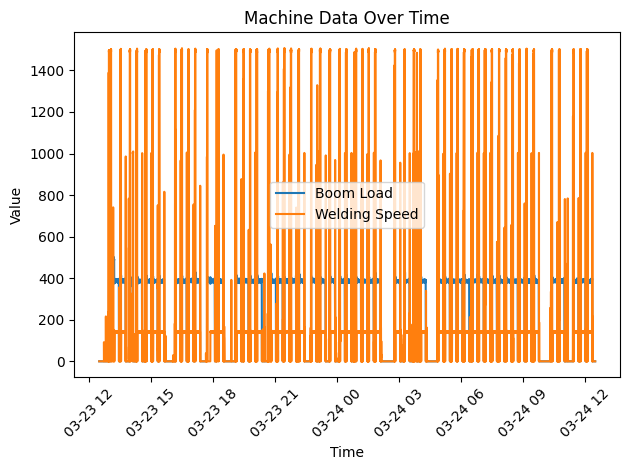

In [10]:
plt.figure()

# Plot both columns
plt.plot(df['Datetime'], df['Boom_Load'], label='Boom Load')
plt.plot(df['Datetime'], df['Welding_Speed'], label='Welding Speed')

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Machine Data Over Time")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

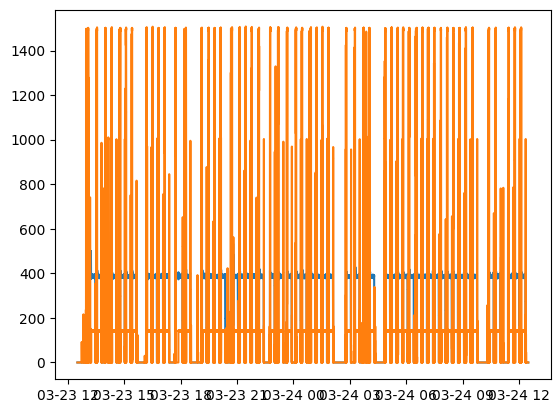

In [11]:
plt.step(df['Datetime'], df['Boom_Load'], label='Boom Load')
plt.step(df['Datetime'], df['Welding_Speed'], label='Welding Speed')

In [12]:
# ------------------ LOGIC ------------------

# Start condition
df['Start_Cond'] = (df['Boom_Load'] > 100) & (df['Welding_Speed'] > 500)

# End condition
df['End_Cond'] = (df['Boom_Load'] < 100) & (df['Welding_Speed'] < 50)

In [13]:
# ------------------ FIND EVENTS ------------------

events = []
in_event = False
start_time = None

In [14]:
for i in range(len(df)):
    
    # Start
    if not in_event and df.loc[i, 'Start_Cond']:
        in_event = True
        start_time = df.loc[i, 'Datetime']
    
    # End
    elif in_event and df.loc[i, 'End_Cond']:
        end_time = df.loc[i, 'Datetime']
        
        duration = end_time - start_time
        
        events.append({
            "Start Time": start_time,
            "End Time": end_time,
            "Duration": duration
        })
        
        in_event = False

# Convert to DataFrame
events_df = pd.DataFrame(events)

print(events_df)

            Start Time            End Time        Duration
0  2026-03-23 12:58:16 2026-03-23 12:59:52 0 days 00:01:36
1  2026-03-23 13:03:27 2026-03-23 13:27:19 0 days 00:23:52
2  2026-03-23 13:30:53 2026-03-23 13:46:55 0 days 00:16:02
3  2026-03-23 13:58:42 2026-03-23 14:07:16 0 days 00:08:34
4  2026-03-23 14:18:58 2026-03-23 14:34:30 0 days 00:15:32
..                 ...                 ...             ...
56 2026-03-24 10:23:44 2026-03-24 10:39:33 0 days 00:15:49
57 2026-03-24 10:45:11 2026-03-24 11:00:43 0 days 00:15:32
58 2026-03-24 11:26:45 2026-03-24 11:41:30 0 days 00:14:45
59 2026-03-24 11:46:36 2026-03-24 12:02:00 0 days 00:15:24
60 2026-03-24 12:06:06 2026-03-24 12:21:24 0 days 00:15:18

[61 rows x 3 columns]


In [18]:
events_df['Duration_sec'] = events_df['Duration'].dt.total_seconds()

In [20]:
events_df.to_excel("event_output.xlsx", index=False)